# 01 · Data understanding

Can employee attributes distinguish observed attrition from retention? This educational analysis uses the fictional IBM HR sample. We inspect schema and data quality first, then reserve a holdout before studying feature relationships. Predictive associations are not causal evidence.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image
from src.config import FIGURES_DIR, METRICS_DIR, FEATURE_COLUMNS
from src.data.load_data import load_data, split_data
from src.data.explore import exploration_tables
data = load_data()
X_train, X_test, y_train, y_test = split_data(data)


## Structural audit

Schema checks do not estimate preprocessing statistics. Missing predictors can be imputed later; missing labels, duplicate rows, invalid types, and unexpected training categories fail clearly.

In [2]:
from src.data.validate_data import data_audit
audit = data_audit(data)
display(Markdown(f'**Shape:** {data.shape[0]:,} rows × {data.shape[1]} columns; 'f'**duplicate rows:** {audit["duplicate_rows"]}.'))
display(pd.DataFrame({'dtype': data.dtypes.astype(str), 'missing': data.isna().sum(), 'unique': data.nunique()}))

**Shape:** 1,470 rows × 35 columns; **duplicate rows:** 0.

,dtype,missing,unique
Age,int64,0,43
Attrition,str,0,2
BusinessTravel,str,0,3
DailyRate,int64,0,886
Department,str,0,3
DistanceFromHome,int64,0,29
Education,int64,0,5
EducationField,str,0,6
EmployeeCount,int64,0,1
EmployeeNumber,int64,0,1470


## Split before learning

The same stratified 80/20 split (seed 42) is reused throughout. `Yes → 1` and `No → 0` remain explicit. Test outcomes are not used for model or threshold selection.

,partition,rows
0,train,1176
1,test,294


,training_count
Attrition,
No,986
Yes,190


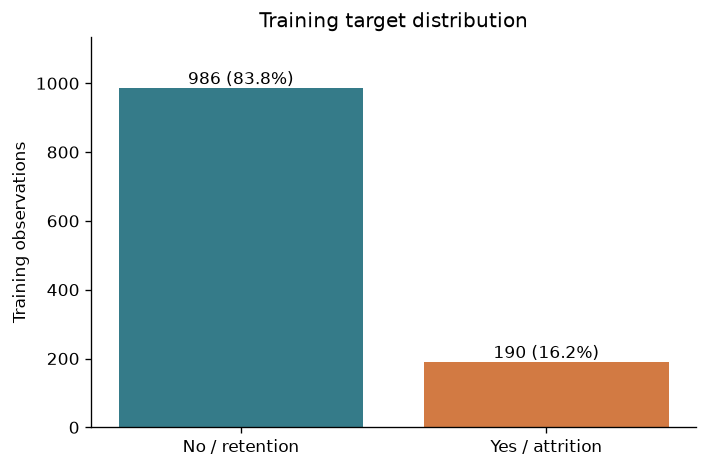

In [3]:
display(pd.DataFrame({'partition': ['train', 'test'], 'rows': [len(X_train), len(X_test)]}))
display(y_train.value_counts().rename(index={0: 'No', 1: 'Yes'}).to_frame('training_count'))
assert set(X_train.index).isdisjoint(X_test.index)
display(Image(filename=str(FIGURES_DIR / 'attrition_distribution.png')))

## Investigate exclusions

A unique ID does not have a portable predictive meaning. Constant columns cannot distinguish outcomes; confirm their values on training rows before removal.

In [4]:
from src.features.preprocess import feature_exclusions
display(pd.Series(feature_exclusions(X_train), name='reason').to_frame())
display(X_train[['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']].nunique().to_frame('unique'))
display(X_train[FEATURE_COLUMNS].describe(include='all').T)

,reason
EmployeeNumber,Unique employee identifier; no portable predic...
EmployeeCount,Confirmed constant in training data (1); no va...
Over18,Confirmed constant in training data ('Y'); no ...
StandardHours,Confirmed constant in training data (80); no v...


,unique
EmployeeCount,1
Over18,1
StandardHours,1
EmployeeNumber,1176


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1176.0,NaN,NaN,NaN,36.998299,9.178142,18.0,30.0,36.0,43.0,60.0
DailyRate,1176.0,NaN,NaN,NaN,803.991497,401.339423,103.0,467.75,799.5,1157.0,1499.0
DistanceFromHome,1176.0,NaN,NaN,NaN,9.357993,8.179803,1.0,2.0,7.0,14.0,29.0
Education,1176.0,NaN,NaN,NaN,2.906463,1.027996,1.0,2.0,3.0,4.0,5.0
EnvironmentSatisfaction,1176.0,NaN,NaN,NaN,2.716837,1.088707,1.0,2.0,3.0,4.0,4.0
HourlyRate,1176.0,NaN,NaN,NaN,65.5,20.373324,30.0,48.0,66.0,83.0,100.0
JobInvolvement,1176.0,NaN,NaN,NaN,2.737245,0.703673,1.0,2.0,3.0,3.0,4.0
JobLevel,1176.0,NaN,NaN,NaN,2.076531,1.091987,1.0,1.0,2.0,3.0,5.0
JobSatisfaction,1176.0,NaN,NaN,NaN,2.719388,1.110644,1.0,2.0,3.0,4.0,4.0
MonthlyIncome,1176.0,NaN,NaN,NaN,6544.02466,4653.743955,1009.0,2948.0,5004.5,8420.5,19973.0


## Key Findings

The audit above establishes the shape, types, missingness, and duplicates from the actual file. Three verified constants and the employee identifier are excluded. Attrition is the minority class, so an all-retained classifier can have misleadingly high accuracy.

## Next Steps

Explore training-only distributions and subgroup sizes, then compare against an explicit dummy baseline.